<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1 Assignment

# Titanic: Survival Analysis

**Welcome to your first bonus assignment! The dataset you'll be working with is the legendary Titanic passenger dataset - one of the most famous datasets in data science.**

**The Titanic sank on April 15, 1912 after colliding with an iceberg. Of 2,224 passengers and crew aboard, only 710 survived. This dataset captures information about 891 of those passengers and your job is to explore it using Pandas and data visualization.**

**We have a set of questions for you that will build your understanding of data manipulation and visualization. GOOD LUCK!**

---

**Dataset columns:**
| Column | Description |
|--------|-------------|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = Did not survive, 1 = Survived |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

---

*Let's get started with importing numpy, pandas, seaborn and matplotlib!*

**Note** - matplotlib should be imported with the command:

`import matplotlib.pyplot as plt`

## Warm-Up Questions

These questions are **ungraded** and help you get comfortable with the dataset.

### 1) Import all important libraries
Import `numpy`, `pandas`, `seaborn`, and `matplotlib.pyplot`.

In [129]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


### 2) Read the CSV file and assign it to a variable
Load `W1_Titanic.csv` into a DataFrame.

In [130]:
df=pd.read_csv('https://github.com/bsoc-bitbyte/Summer-of-ML-26/raw/main/SoM-2026/Week-1/Bonus/W1_Titanic.csv',sep=",")

### 3) Display the shape of the DataFrame
Expected Output: `(891, 12)`

In [131]:
df.shape

(891, 12)

### 4) Print all column names of the DataFrame
Return an array/index containing the names of all columns.

In [132]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### 5) Display the first 5 rows and the data types of each column
Use `.head()` and `.dtypes`.

In [133]:
df.head()
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

### 6) Check for missing values
Print the count of missing values in each column. 

*Hint: use `.isnull().sum()`*

In [134]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 7) Set `PassengerId` as the index of the DataFrame
Update the DataFrame in-place.

In [135]:
df.set_index('PassengerId',inplace=True)

### 8) Create a new column `FamilySize` = `SibSp` + `Parch` + 1
This represents the total number of family members aboard (including the passenger themselves).

In [136]:
df['Family Size']= df['SibSp'].astype(int)+df['Parch'].astype(int)+1


## GRADED Questions

### Answer these questions in the quiz. BEST OF LUCK!!

### 1. How many passengers survived?

In [137]:
print(df['Survived'].sum())

342


### 2. What is the average age of passengers who survived vs. those who did not?

*Hint: Use `groupby` on the `Survived` column, then take the mean of `Age`.*

*Note: Round your answer to 2 decimal places.*

In [138]:
print(df.groupby('Survived')['Age'].mean())


Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


### 3. What percentage (up to 2 decimal places) of female passengers survived?

In [139]:
tot=df['Sex'].str.count('female').sum()
ava=df.loc[df['Sex']=='female','Survived'].sum()
print(f"{((ava/tot)*100):.2f}%")

74.20%


### 4. Which passenger class (Pclass) had the highest survival rate?

*Hint: Group by `Pclass` and find the mean of `Survived` for each class.*

In [140]:
df.groupby('Pclass')['Survived'].mean().idxmax()

1

### 5. What is the name of the passenger who paid the highest fare?

In [141]:
df.loc[df['Fare']==df['Fare'].max(),'Name'].tolist()

['Ward, Miss. Anna',
 'Cardeza, Mr. Thomas Drake Martinez',
 'Lesurer, Mr. Gustave J']

### 6. Using seaborn, make the following plots, observe the trends, and answer the questions given in the form.

**Plot A** — Survival count by passenger class (bar plot)

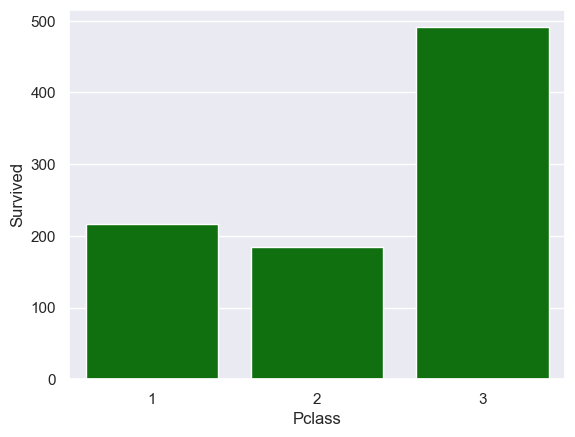

In [153]:
sns.set_style('darkgrid')
sns.barplot(data=df.groupby('Pclass')['Survived'].count(),color="green")
plt.show()

**Plot B** — Age distribution of survivors vs. non-survivors (histogram / KDE plot)

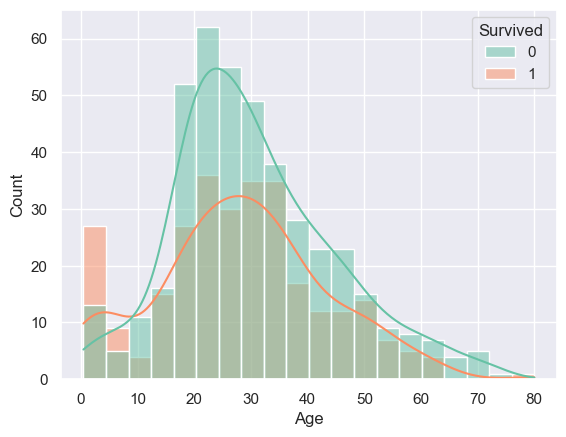

In [143]:
df1=df.dropna(subset=['Age'])
sns.histplot(data=df1,x='Age',hue='Survived',palette="Set2", kde=True)
plt.show()

**Plot C** — Average fare by embarkation port (bar plot) — *Complete the missing line*

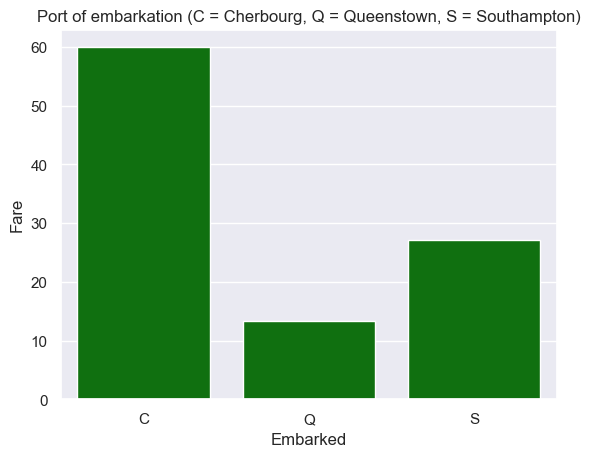

In [152]:
plt.title("Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)")
sns.barplot(data=df.groupby('Embarked')['Fare'].mean(),color="green")
plt.show()

### 7. Among male passengers in 3rd class, how many survived?

In [145]:
df.loc[(df['Sex']=='male') & (df['Pclass']==3),'Survived'].sum()

47

### 8. How many passengers under the age of 10 were on board, and what fraction of them survived?

*Note: Ignore passengers with missing Age values. Round the fraction to 2 decimal places.*

In [146]:
newdf=df.loc[df['Age']==10,'Survived']
total_bachhe=len(newdf.tolist())
zinda_bachhe=newdf.sum()*100
print(f"{(zinda_bachhe/total_bachhe):.2f}%")

0.00%


---

## Bonus Questions

### These are UNGRADED and are given as an extra challenge.

---

### Which cabin deck (first letter of the Cabin column, e.g. 'C' for 'C85') had the highest survival rate?

*Hint: Extract the first character of the `Cabin` column after dropping rows where `Cabin` is null.*

In [147]:

df['deck']=df['Cabin'].str[0]
(df.groupby('deck')['Survived'].mean()*100).idxmin()

'T'

### Extract titles from passenger names (e.g. 'Mr', 'Mrs', 'Miss') and find the most common title among survivors.

*Hint: The Name column looks like `Braund, Mr. Owen Harris` — extract the word between `, ` and `.`*

In [148]:
df['Title']=df['Name'].str.split(',').str[1].str.split('.').str[0]
newdf=df.loc[df['Survived']==1,'Title']
print(newdf.value_counts().idxmax())

 Miss


### Plot a heatmap of the correlation matrix of all numeric columns.

*Use `seaborn.heatmap` with `annot=True`. Which two features are most positively correlated?*

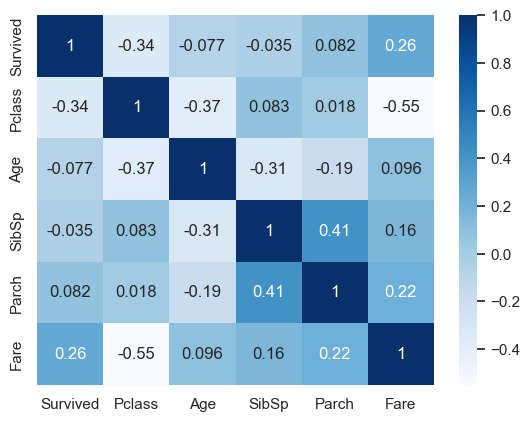

In [149]:
col=["Survived","Pclass","Age","SibSp","Parch","Fare"]
sns.heatmap(data=df[col].corr(),annot=True,cmap="Blues")
plt.show()


### Among passengers travelling alone (FamilySize == 1), what was the survival rate compared to those with family?

*You'll need to first create the `FamilySize` column (from the warm-up), then group.*

In [150]:
df.groupby('Family Size')['Survived'].sum()

Family Size
1     163
2      89
3      59
4      21
5       3
6       3
7       4
8       0
11      0
Name: Survived, dtype: int64

### Which age group (bin them in 10-year intervals: 0-10, 10-20, 20-30, ...) had the lowest survival rate?

In [151]:
bins=[0,10,20,30,40,50,60,70,80]
labels= ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
df['age_grp']=pd.cut(df['Age'],bins=bins,labels=labels)
df.groupby('age_grp')['Survived'].sum().idxmin()


'70-80'